Cooling Energy Integration starting with 10 Runs

CSV: /home/aamy/Documents/hfe-system/data/raw/recirculation/log_20260424_153546.csv
Available columns:
['time_s', 'U0_C', 'U1_C', 'TTEST_C', 'TFO_C', 'TTI_C', 'U5_C', 'TTO_C', 'TMI_C', 'THM_C', 'THI_C', 'valve', 'mode', 'pump_cmd_pct', 'pump_freq_hz', 'pump_rotation_speed_rpm', 'pump_input_power_kw', 'pump_input_power_w', 'pump_output_current_a', 'pump_output_voltage_v', 'pump_pressure_before_bar_abs', 'pump_pressure_after_bar_abs', 'pump_pressure_tank_bar_abs', 'pump_pressure_error_bar', 'pump_max_freq_hz', 'fluid_meter_valid', 'fluid_concentration_pct', 'fluid_flow_velocity_mps', 'fluid_volume_flow_m3s', 'fluid_mass_flow_kgs', 'fluid_temperature_c', 'fluid_density_kg_m3', 'fluid_delta_p_bar', 'scale_weight_kg', 'scale_age_s', 'scale_tare_kg']

Valve shutoff times used for C1-C38:
run  t_shutoff_min
 C1       9.343083
 C2      15.339683
 C3      18.163600
 C4      21.022200
 C5      24.334183
 C6      27.576517
 C7      31.027917
 C8      34.340033
 C9      36.641450
C10      40.12778

,cycle,run_number,C_total_J_per_K,C_total_source,t_off_min,T_off_C,t_min_min,T_min_C,t_next_open_min,T_next_open_C,...,deltaT_THM_LN2_K,cooling_power_open_W,heat_transfer_W_per_K,u_THM_for_G_C,u_deltaT_THM_LN2_K,sigma_cooldown_rate_open_C_per_s,sigma_cooling_power_open_W,sigma_heat_transfer_W_per_K,Qdot_residual_W,excluded_from_analysis
0,C1,1,560.747213,warmup_rate,9.343083,-89.785739,9.447650,-91.419349,11.783617,-29.857001,...,106.014261,150.356829,1.418270,0.572532,0.574625,0.001677,2.250715,0.022579,146.006105,True
1,C2,2,419.297296,warmup_rate,15.339683,-101.943759,15.444283,-102.230878,16.664567,-59.222380,...,93.856241,164.852144,1.756432,0.689706,0.691444,0.004581,2.952212,0.034012,19.182340,False
2,C3,3,424.354945,warmup_rate,18.163600,-100.706175,18.442500,-104.191210,19.627750,-62.915328,...,95.093825,245.347429,2.580056,0.677708,0.679477,0.010925,5.712048,0.062833,88.376465,False
3,C4,4,435.822995,warmup_rate,21.022200,-101.240811,21.370817,-105.468396,22.521233,-66.459767,...,94.559189,252.102336,2.666080,0.682889,0.684645,0.011895,6.215273,0.068505,88.085228,False
4,C5,5,475.087604,warmup_rate,24.334183,-110.893962,24.578217,-112.151347,25.937950,-69.855696,...,84.906038,286.642278,3.375994,0.776830,0.778374,0.010180,6.211808,0.079438,40.798245,False
5,C6,6,527.443959,warmup_rate,27.576517,-110.656346,27.820617,-112.765188,29.249983,-72.716989,...,85.143654,313.117107,3.677515,0.774510,0.776059,0.011290,7.320888,0.092285,75.945380,False
6,C7,7,583.180949,warmup_rate,31.027917,-110.992968,31.306817,-114.022573,32.736417,-77.796031,...,84.807032,286.526251,3.378567,0.777797,0.779339,0.010509,7.262794,0.091093,105.581895,False
7,C8,8,2469.998002,warmup_rate,34.340033,-110.923664,34.724000,-115.507673,35.246917,-112.379062,...,84.876336,1118.116869,13.173482,0.777120,0.778664,0.011756,32.778578,0.404661,491.470303,True
8,C9,9,699.682952,warmup_rate,36.641450,-119.002608,36.885483,-121.566881,38.733333,-82.538451,...,76.797392,73.876115,0.961961,0.856186,0.857587,0.014685,10.324076,0.134861,122.536400,False
9,C10,10,443.311880,warmup_rate,40.127783,-114.002771,41.034333,-122.210424,42.463800,-74.558513,...,81.797229,181.007996,2.212887,0.807214,0.808700,0.014340,6.817213,0.086167,66.893720,False


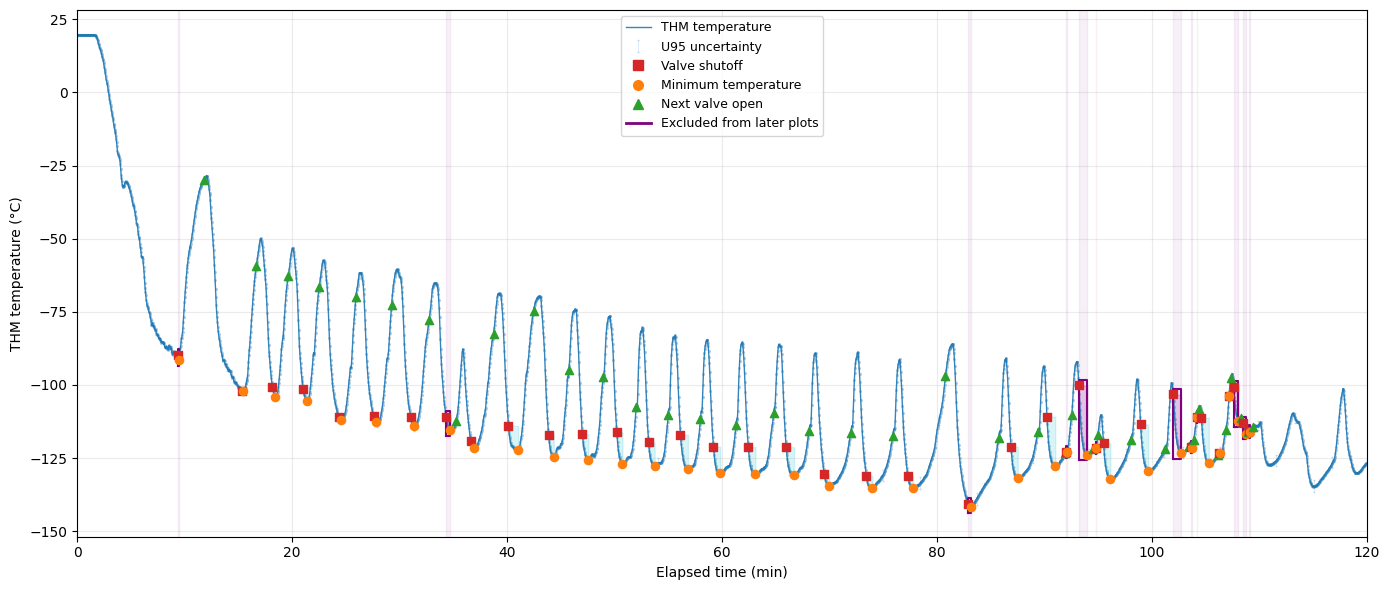

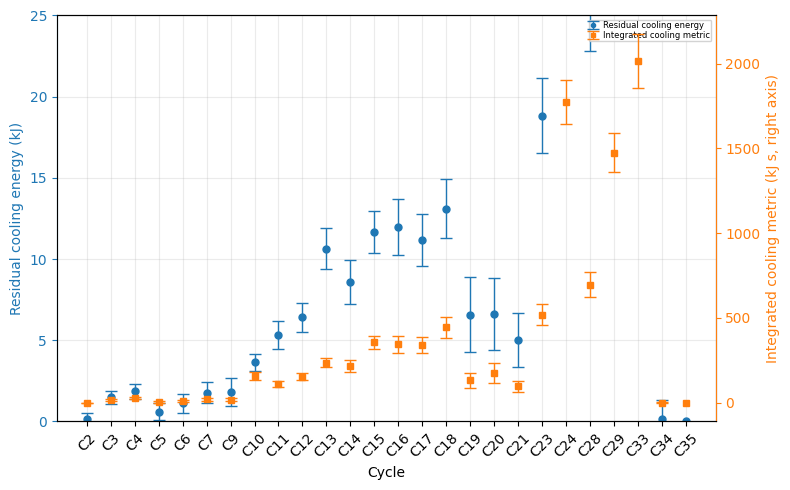

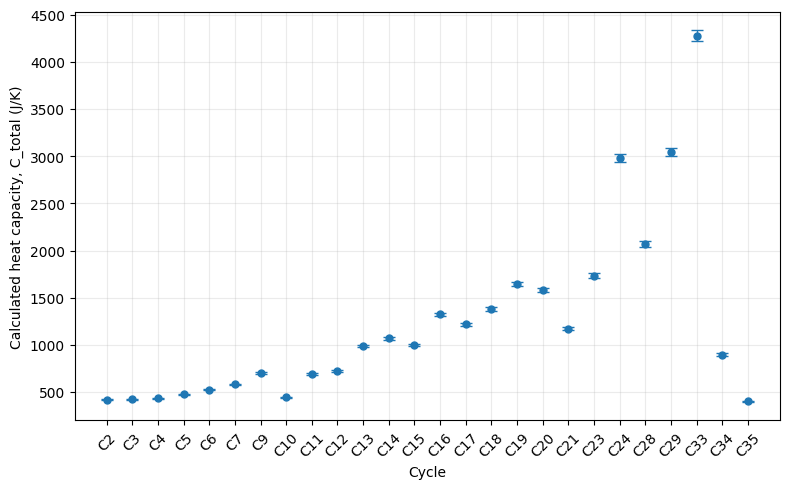

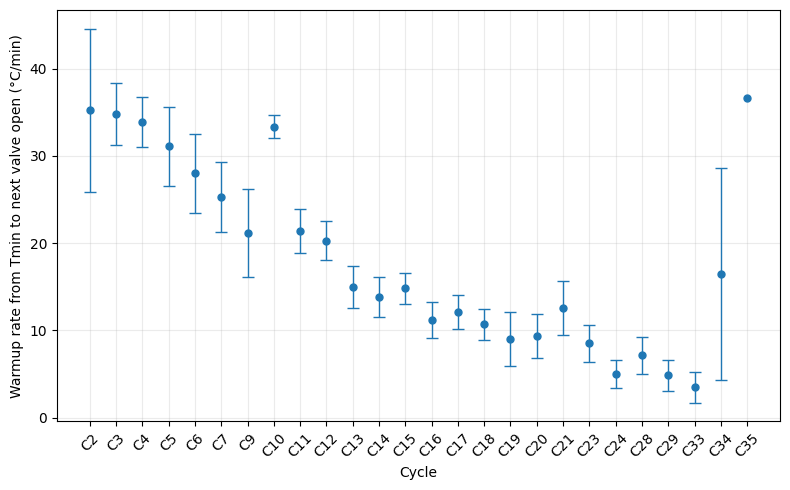

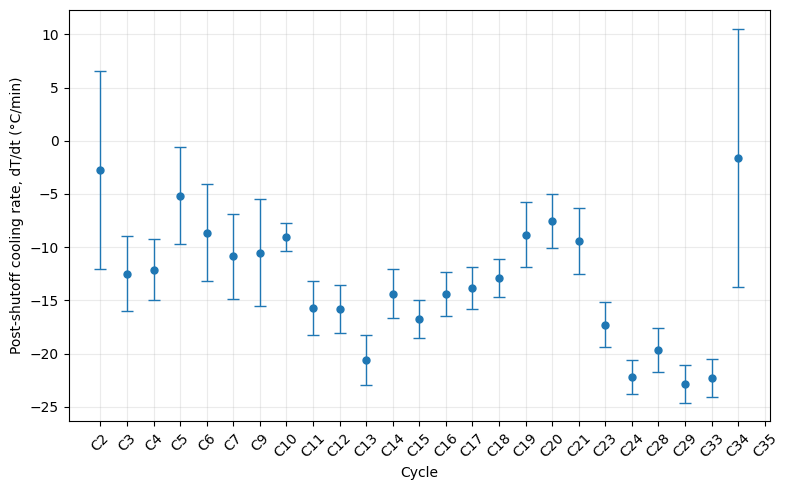

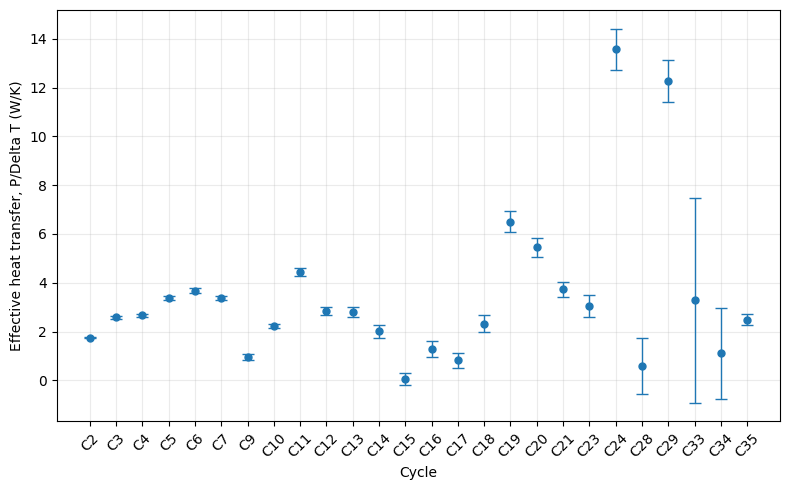

Best-fit equation excluding C24 and C29: heat_transfer_W_per_K = -0.040059 * deltaT_THM_LN2_K + 5.824760
Best-fit R^2 excluding C24 and C29: 0.053536


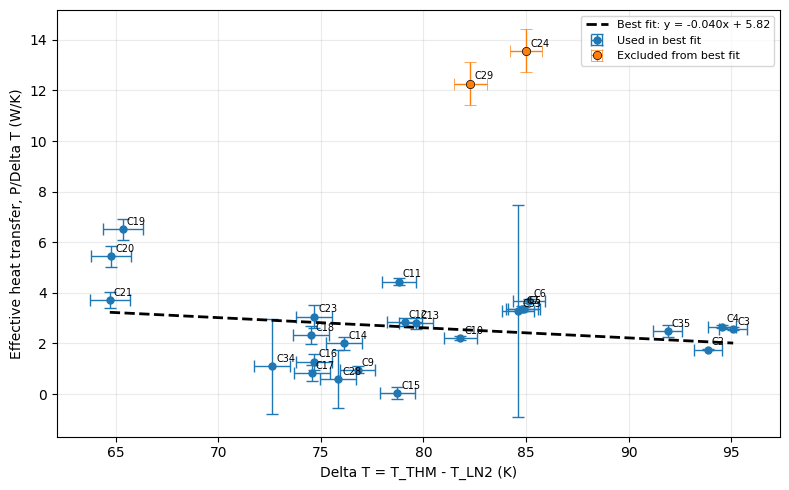

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import trapezoid
from scipy.stats import linregress


# ============================================================
# 1. SETTINGS
# ============================================================

RUN_START = 1
RUN_END = 38

PLOT_START_MIN = 0.0
PLOT_END_MIN = 120.0

EXCLUDED_CYCLES = [
    "C1", "C8", "C22", "C25", "C26", "C27",
    "C30", "C31", "C32", "C36", "C37", "C38"
]

HEAT_LEAK_W = 246.3

LN2_TEMP_C = -195.8
U_LN2_C = 0.049

THM_GAIN = 0.990066718500
THM_OFFSET_C = -0.434417973250

U_NOISE_THM_C = 0.0440
U_CAL_THM_C = 0.1617
SIGMA_C_FRAC = 0.0136


# ============================================================
# 2. UNCERTAINTY FUNCTIONS
# ============================================================

def thm_model_uncertainty_C(T_C):
    T_C = np.asarray(T_C, dtype=float)
    return 0.01 * np.maximum(0, -35.04 - T_C)


def thm_cal_uncertainty_C(T_C):
    T_C = np.asarray(T_C, dtype=float)
    return np.full_like(T_C, U_CAL_THM_C)


def thm_instantaneous_uncertainty_C(T_C):
    T_C = np.asarray(T_C, dtype=float)

    u_cal = thm_cal_uncertainty_C(T_C)
    u_noise = U_NOISE_THM_C
    u_model = thm_model_uncertainty_C(T_C)

    return np.sqrt(u_cal**2 + u_noise**2 + u_model**2)


def thm_U95_C(T_C):
    return 2.0 * thm_instantaneous_uncertainty_C(T_C)


def c_total_from_warmup_rate(warmup_rate_C_per_s):
    if not np.isfinite(warmup_rate_C_per_s):
        return np.nan

    if warmup_rate_C_per_s <= 0:
        return np.nan

    return HEAT_LEAK_W / warmup_rate_C_per_s


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def find_repo_root():
    repo_root = Path.cwd()

    for candidate in [repo_root, *repo_root.parents]:
        if (candidate / "data").exists() and (candidate / "analysis").exists():
            return candidate

    return repo_root


def clean_axes(xlabel, ylabel, title, rotate_xticks=True):
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.25)

    if rotate_xticks:
        plt.xticks(rotation=45)

    plt.tight_layout()


def plot_metric_vs_cycle(data_df, y_col, yerr_col, ylabel, title):
    plt.figure(figsize=(8, 5))

    plt.errorbar(
        data_df["cycle"],
        data_df[y_col],
        yerr=data_df[yerr_col],
        fmt="o",
        linestyle="none",
        capsize=4,
        markersize=5,
        elinewidth=1,
    )

    clean_axes(
        xlabel="Cycle",
        ylabel=ylabel,
        title=title,
        rotate_xticks=True
    )

    plt.show()


# ============================================================
# 4. LOAD CSV DATA
# ============================================================

repo_root = find_repo_root()

csv_path = repo_root / "data" / "raw" / "recirculation" / "log_20260424_153546.csv"

if not csv_path.exists():
    csv_path = Path("log_20260424_153546.csv")

df = pd.read_csv(csv_path, comment="#")

print("CSV:", csv_path)
print("Available columns:")
print(df.columns.tolist())


# ============================================================
# 5. CLEAN AND CORRECT DATA
# ============================================================

df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")
df["THM_C"] = pd.to_numeric(df["THM_C"], errors="coerce")
df["valve"] = pd.to_numeric(df["valve"], errors="coerce")
df["mode"] = df["mode"].astype(str).str.strip().str.upper()

df["THM_corr_C"] = THM_GAIN * df["THM_C"] + THM_OFFSET_C

df["ln_valve_closed"] = (
    df["mode"].eq("C") |
    (df["mode"].eq("A") & df["valve"].eq(0))
)

df["ln_valve_open"] = ~df["ln_valve_closed"]

time_raw = df["time_s"].to_numpy(dtype=float)
T_raw = df["THM_corr_C"].to_numpy(dtype=float)
valve_raw = df["ln_valve_open"].to_numpy()

time_min = (time_raw - time_raw[0]) / 60.0

valid = np.isfinite(time_min) & np.isfinite(T_raw) & pd.notna(valve_raw)

time_min = time_min[valid]
T_raw = T_raw[valid]
valve_raw = valve_raw[valid]

order = np.argsort(time_min)

time_min = time_min[order]
T_raw = T_raw[order]
valve_raw = valve_raw[order]


# ============================================================
# 6. SELECT TIME WINDOW
# ============================================================

window_mask = (time_min >= 0) & (time_min <= 350)

t_run = time_min[window_mask]
T_run = T_raw[window_mask]
valve_run_raw = valve_raw[window_mask]

if len(t_run) == 0:
    raise ValueError("No data points found in the selected time window.")

plot_mask = (t_run >= PLOT_START_MIN) & (t_run <= PLOT_END_MIN)


# ============================================================
# 7. CONVERT VALVE STATE TO BOOLEAN
# ============================================================

if valve_run_raw.dtype == bool:
    valve_open = valve_run_raw
else:
    valve_open = (
        pd.Series(valve_run_raw)
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["1", "true", "open", "o"])
        .to_numpy()
    )


# ============================================================
# 8. FIND VALVE TRANSITIONS
# ============================================================

close_indices_all = np.where(valve_open[:-1] & ~valve_open[1:])[0] + 1
open_indices_all = np.where(~valve_open[:-1] & valve_open[1:])[0] + 1

if len(close_indices_all) == 0:
    raise ValueError("No open-to-closed valve transition found.")

run_numbers_all = np.arange(1, len(close_indices_all) + 1, dtype=int)

selected = (run_numbers_all >= RUN_START) & (run_numbers_all <= RUN_END)

run_numbers = run_numbers_all[selected]
close_indices = close_indices_all[selected]

if len(close_indices) == 0:
    raise ValueError(f"No LN-valve shutoff runs found for C{RUN_START}-C{RUN_END}.")

selected_shutoffs = pd.DataFrame({
    "run": [f"C{run}" for run in run_numbers],
    "t_shutoff_min": t_run[close_indices],
})

print(f"\nValve shutoff times used for C{RUN_START}-C{RUN_END}:")
print(selected_shutoffs.to_string(index=False))


# ============================================================
# 9. CALCULATE LN-VALVE-OPEN COOLDOWN RATES
# ============================================================

open_rate_results = []

for run_number, i_close in zip(run_numbers, close_indices):
    cycle_name = f"C{run_number}"

    if run_number == 1:
        i_start = 0
    else:
        i_start = close_indices_all[run_number - 2]

    open_mask = valve_open[i_start:i_close]

    t_open = t_run[i_start:i_close][open_mask]
    T_open = T_run[i_start:i_close][open_mask]

    if len(t_open) < 2:
        continue

    slope_C_per_min, intercept = np.polyfit(t_open, T_open, 1)

    open_rate_results.append({
        "cycle": cycle_name,
        "t_open_start_min": t_open[0],
        "t_first_close_min": t_run[i_close],
        "T_open_start_C": T_open[0],
        "T_first_close_C": T_run[i_close],
        "cooldown_rate_open_C_per_min": slope_C_per_min,
        "cooldown_rate_open_C_per_s": slope_C_per_min / 60.0,
    })

open_rate_df = pd.DataFrame(open_rate_results)


# ============================================================
# 10. CALCULATE C_TOTAL AND RESIDUAL COOLING
# ============================================================

results = []

for run_number, i_off in zip(run_numbers, close_indices):
    cycle_name = f"C{run_number}"

    next_open = open_indices_all[open_indices_all > i_off]
    i_next_open = int(next_open[0]) if len(next_open) else len(t_run) - 1
    i_end = i_next_open

    t_cycle = t_run[i_off:i_end + 1]
    T_cycle = T_run[i_off:i_end + 1]

    if len(t_cycle) < 2:
        continue

    t_off = t_cycle[0]
    T_off = T_cycle[0]

    i_min_local = np.argmin(T_cycle)

    t_min = t_cycle[i_min_local]
    T_min = T_cycle[i_min_local]

    t_next_open = t_run[i_next_open]
    T_next_open = T_run[i_next_open]

    dt_warmup_min = t_next_open - t_min
    dt_warmup_s = dt_warmup_min * 60.0

    if dt_warmup_min > 0:
        warmup_rate_C_per_min = (T_next_open - T_min) / dt_warmup_min
        warmup_rate_C_per_s = warmup_rate_C_per_min / 60.0
    else:
        warmup_rate_C_per_min = np.nan
        warmup_rate_C_per_s = np.nan

    C_TOTAL = c_total_from_warmup_rate(warmup_rate_C_per_s)

    if np.isfinite(C_TOTAL):
        C_TOTAL_source = "warmup_rate"
    else:
        C_TOTAL_source = "invalid_warmup"

    t_section = t_cycle[:i_min_local + 1]
    T_section = T_cycle[:i_min_local + 1]

    residual_area_C_min = trapezoid(T_off - T_section, t_section)

    deltaT_C = T_off - T_min

    Q_overshoot_J = C_TOTAL * deltaT_C
    integrated_metric_J_s = C_TOTAL * residual_area_C_min * 60.0

    dt_after_off_min = t_min - t_off
    dt_after_off_s = dt_after_off_min * 60.0

    if dt_after_off_min == 0:
        cooling_rate_C_per_min = np.nan
        cooling_rate_C_per_s = np.nan
    else:
        cooling_rate_C_per_min = (T_min - T_off) / dt_after_off_min
        cooling_rate_C_per_s = cooling_rate_C_per_min / 60.0

    results.append({
        "cycle": cycle_name,
        "run_number": run_number,

        "C_total_J_per_K": C_TOTAL,
        "C_total_source": C_TOTAL_source,

        "t_off_min": t_off,
        "T_off_C": T_off,

        "t_min_min": t_min,
        "T_min_C": T_min,

        "t_next_open_min": t_next_open,
        "T_next_open_C": T_next_open,

        "dt_warmup_min": dt_warmup_min,
        "dt_warmup_s": dt_warmup_s,
        "warmup_rate_C_per_min": warmup_rate_C_per_min,
        "warmup_rate_C_per_s": warmup_rate_C_per_s,

        "deltaT_C": deltaT_C,
        "dt_after_off_min": dt_after_off_min,
        "dt_after_off_s": dt_after_off_s,

        "cooling_rate_C_per_min": cooling_rate_C_per_min,
        "cooling_rate_C_per_s": cooling_rate_C_per_s,

        "area_C_min": residual_area_C_min,
        "Q_overshoot_kJ": Q_overshoot_J / 1000.0,
        "integrated_metric_kJ_s": integrated_metric_J_s / 1000.0,

        "u_T_off_C": float(thm_instantaneous_uncertainty_C(T_off)),
        "u_T_min_C": float(thm_instantaneous_uncertainty_C(T_min)),
        "U95_T_off_C": float(thm_U95_C(T_off)),
        "U95_T_min_C": float(thm_U95_C(T_min)),
    })

results_df = pd.DataFrame(results)

results_df = results_df.merge(open_rate_df, on="cycle", how="left")


# ============================================================
# 11. UNCERTAINTY CALCULATIONS
# ============================================================

results_df["sigma_deltaT_C"] = np.sqrt(
    results_df["u_T_off_C"]**2 +
    results_df["u_T_min_C"]**2
)

results_df["sigma_C_total_J_per_K"] = (
    SIGMA_C_FRAC * results_df["C_total_J_per_K"]
)

relative_uncertainty = np.sqrt(
    (results_df["sigma_C_total_J_per_K"] / results_df["C_total_J_per_K"])**2
    +
    (results_df["sigma_deltaT_C"] / results_df["deltaT_C"].abs())**2
)

results_df["sigma_Q_overshoot_kJ"] = (
    results_df["Q_overshoot_kJ"].abs() * relative_uncertainty
)

results_df["sigma_integrated_metric_kJ_s"] = (
    results_df["integrated_metric_kJ_s"].abs() * relative_uncertainty
)

results_df["sigma_cooling_rate_C_per_min"] = (
    results_df["sigma_deltaT_C"] /
    results_df["dt_after_off_min"].replace(0, np.nan)
)

results_df["sigma_cooldown_rate_open_C_per_min"] = (
    results_df["sigma_deltaT_C"] /
    (
        results_df["t_first_close_min"] -
        results_df["t_open_start_min"]
    ).replace(0, np.nan)
)


# ============================================================
# 12. EFFECTIVE HEAT TRANSFER CALCULATION
# ============================================================

results_df["deltaT_THM_LN2_K"] = (
    results_df["T_first_close_C"] - LN2_TEMP_C
)

results_df["cooling_power_open_W"] = (
    results_df["C_total_J_per_K"] *
    results_df["cooldown_rate_open_C_per_s"].abs()
)

results_df["heat_transfer_W_per_K"] = (
    results_df["cooling_power_open_W"] /
    results_df["deltaT_THM_LN2_K"]
)

results_df["u_THM_for_G_C"] = results_df["T_first_close_C"].apply(
    lambda T_val: float(thm_instantaneous_uncertainty_C(T_val))
)

results_df["u_deltaT_THM_LN2_K"] = np.sqrt(
    results_df["u_THM_for_G_C"]**2 + U_LN2_C**2
)

results_df["sigma_cooldown_rate_open_C_per_s"] = (
    results_df["sigma_cooldown_rate_open_C_per_min"] / 60.0
)

results_df["sigma_cooling_power_open_W"] = (
    results_df["cooling_power_open_W"].abs()
    *
    np.sqrt(
        (results_df["sigma_C_total_J_per_K"] / results_df["C_total_J_per_K"])**2
        +
        (
            results_df["sigma_cooldown_rate_open_C_per_s"] /
            results_df["cooldown_rate_open_C_per_s"].abs()
        )**2
    )
)

results_df["sigma_heat_transfer_W_per_K"] = (
    results_df["heat_transfer_W_per_K"].abs()
    *
    np.sqrt(
        (
            results_df["sigma_cooling_power_open_W"] /
            results_df["cooling_power_open_W"].abs()
        )**2
        +
        (
            results_df["u_deltaT_THM_LN2_K"] /
            results_df["deltaT_THM_LN2_K"]
        )**2
    )
)


# ============================================================
# 13. DEFINE EXCLUDED RUNS AND FILTERED DATA
# ============================================================

results_df["Qdot_residual_W"] = (
    results_df["Q_overshoot_kJ"] * 1000
    / results_df["dt_after_off_s"]
)

results_df["excluded_from_analysis"] = results_df["cycle"].isin(EXCLUDED_CYCLES)

results_used_df = results_df[~results_df["excluded_from_analysis"]].copy()
results_excluded_df = results_df[results_df["excluded_from_analysis"]].copy()

fit_df = results_used_df.copy()

print("\nFinal results table, all cycles:")
print(results_df.to_string(index=False))

print("\nCycles excluded from later plots:")
print(results_excluded_df[["cycle", "run_number"]].to_string(index=False))

print("\nCycles used in later plots:")
print(results_used_df[["cycle", "run_number"]].to_string(index=False))

try:
    display(results_df)
except NameError:
    pass


# ============================================================
# 14. PLOT: THM TEMPERATURE WITH RESIDUAL COOLING AREAS
#     EXCLUDED RUNS SHADED PURPLE AND BOXED
# ============================================================

plt.figure(figsize=(14, 6))

PLOT_DISPLAY_END_MIN = PLOT_END_MIN
plot_windows = [(PLOT_START_MIN, PLOT_DISPLAY_END_MIN)]

temperature_label = "THM temperature"
uncertainty_label = "U95 uncertainty"

for window_start, window_end in plot_windows:
    segment_mask = (t_run >= window_start) & (t_run <= window_end)
    plot_t = t_run[segment_mask]
    plot_T = T_run[segment_mask]

    if len(plot_t) == 0:
        continue

    plt.plot(
        plot_t,
        plot_T,
        color="tab:blue",
        linewidth=1.0,
        alpha=0.9,
        label=temperature_label or "_nolegend_"
    )
    temperature_label = None

    plt.scatter(
        plot_t,
        plot_T,
        s=5,
        color="tab:blue",
        alpha=0.35,
        linewidths=0
    )

    plt.errorbar(
        plot_t,
        plot_T,
        yerr=thm_U95_C(plot_T),
        fmt="none",
        ecolor="tab:blue",
        elinewidth=0.4,
        capsize=1.0,
        errorevery=50,
        alpha=0.25,
        label=uncertainty_label or "_nolegend_"
    )
    uncertainty_label = None


def time_in_plot_windows(t_value):
    return any(start <= t_value <= end for start, end in plot_windows)


for _, row in results_df.iterrows():
    t_off = row["t_off_min"]
    t_min = row["t_min_min"]
    T_off = row["T_off_C"]
    T_min = row["T_min_C"]
    t_next_open = row["t_next_open_min"]
    is_excluded = row["excluded_from_analysis"]

    if not any(t_min >= start and t_off <= end for start, end in plot_windows):
        continue

    for window_start, window_end in plot_windows:
        shade_mask = (
            (t_run >= max(t_off, window_start)) &
            (t_run <= min(t_min, window_end))
        )

        if not np.any(shade_mask):
            continue

        if is_excluded:
            plt.fill_between(
                t_run[shade_mask],
                T_run[shade_mask],
                T_off,
                color="purple",
                alpha=0.18
            )

            plt.axvspan(
                max(t_off, window_start),
                min(t_min, window_end),
                color="purple",
                alpha=0.06
            )

        else:
            plt.fill_between(
                t_run[shade_mask],
                T_run[shade_mask],
                T_off,
                color="tab:cyan",
                alpha=0.16
            )

    if is_excluded and time_in_plot_windows(t_off) and time_in_plot_windows(t_min):
        y_bottom = min(T_min, T_off) - 2
        y_top = max(T_min, T_off) + 2

        plt.plot(
            [t_off, t_min, t_min, t_off, t_off],
            [y_bottom, y_bottom, y_top, y_top, y_bottom],
            color="purple",
            linewidth=1.5,
            zorder=6
        )

    if time_in_plot_windows(t_off):
        plt.scatter(
            t_off,
            T_off,
            marker="s",
            s=35,
            color="tab:red",
            zorder=7
        )

    if time_in_plot_windows(t_min):
        plt.scatter(
            t_min,
            row["T_min_C"],
            marker="o",
            s=35,
            color="tab:orange",
            zorder=7
        )

    if time_in_plot_windows(t_next_open):
        plt.scatter(
            t_next_open,
            row["T_next_open_C"],
            marker="^",
            s=35,
            color="tab:green",
            zorder=7
        )

plt.xlim(PLOT_START_MIN, PLOT_DISPLAY_END_MIN)

clean_axes(
    xlabel="Elapsed time (min)",
    ylabel="THM temperature (°C)",
    title=f"THM Residual Cooling Areas and Warmup Points, C{RUN_START}-C{RUN_END}",
    rotate_xticks=False
)

marker_handles = [
    Line2D(
        [0], [0],
        marker="s",
        linestyle="none",
        markerfacecolor="tab:red",
        markeredgecolor="tab:red",
        markersize=7,
        label="Valve shutoff"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="tab:orange",
        markeredgecolor="tab:orange",
        markersize=7,
        label="Minimum temperature"
    ),
    Line2D(
        [0], [0],
        marker="^",
        linestyle="none",
        markerfacecolor="tab:green",
        markeredgecolor="tab:green",
        markersize=7,
        label="Next valve open"
    ),
    Line2D(
        [0], [0],
        color="purple",
        linewidth=2,
        label="Excluded from later plots"
    ),
]

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles + marker_handles,
    labels + [handle.get_label() for handle in marker_handles],
    fontsize=9
)

plt.show()


# ============================================================
# 15. CLEAN SUMMARY PLOTS, EXCLUDING SELECTED RUNS
# ============================================================

fig, ax_energy = plt.subplots(figsize=(8, 5))

energy_color = "tab:blue"
metric_color = "tab:orange"

ax_energy.errorbar(
    results_used_df["cycle"],
    results_used_df["Q_overshoot_kJ"],
    yerr=results_used_df["sigma_Q_overshoot_kJ"],
    fmt="o",
    linestyle="none",
    capsize=4,
    markersize=5,
    elinewidth=1,
    color=energy_color,
    ecolor=energy_color,
    markerfacecolor=energy_color,
    markeredgecolor=energy_color,
    label="Residual cooling energy"
)

ax_energy.set_xlabel("Cycle")
ax_energy.set_ylabel("Residual cooling energy (kJ)", color=energy_color)
ax_energy.set_ylim(0, 25)
ax_energy.tick_params(axis="x", rotation=45)
ax_energy.tick_params(axis="y", colors=energy_color)
ax_energy.spines["left"].set_color(energy_color)
ax_energy.grid(True, alpha=0.25)

ax_metric = ax_energy.twinx()

ax_metric.errorbar(
    results_used_df["cycle"],
    results_used_df["integrated_metric_kJ_s"],
    yerr=results_used_df["sigma_integrated_metric_kJ_s"],
    fmt="s",
    linestyle="none",
    capsize=4,
    markersize=5,
    elinewidth=1,
    color=metric_color,
    ecolor=metric_color,
    markerfacecolor=metric_color,
    markeredgecolor=metric_color,
    label="Integrated cooling metric"
)

ax_metric.set_ylabel("Integrated cooling metric (kJ s, right axis)", color=metric_color)
ax_metric.tick_params(axis="y", colors=metric_color)
ax_metric.spines["right"].set_color(metric_color)

lines_energy, labels_energy = ax_energy.get_legend_handles_labels()
lines_metric, labels_metric = ax_metric.get_legend_handles_labels()

ax_energy.legend(
    lines_energy + lines_metric,
    labels_energy + labels_metric,
    loc="upper right",
    fontsize=6,
    markerscale=0.6,
    handlelength=0.8,
    borderpad=0.15,
    labelspacing=0.15,
    framealpha=0.85
)

fig.tight_layout()
plt.show()


plot_metric_vs_cycle(
    data_df=results_used_df,
    y_col="C_total_J_per_K",
    yerr_col="sigma_C_total_J_per_K",
    ylabel="Calculated heat capacity, C_total (J/K)",
    title=f"Calculated Heat Capacity from Warmup Rate, excluding selected cycles"
)


plot_metric_vs_cycle(
    data_df=results_used_df,
    y_col="warmup_rate_C_per_min",
    yerr_col="sigma_cooling_rate_C_per_min",
    ylabel="Warmup rate from Tmin to next valve open (°C/min)",
    title=f"THM Warmup Rate Used for C_total, excluding selected cycles"
)


plot_metric_vs_cycle(
    data_df=results_used_df,
    y_col="cooling_rate_C_per_min",
    yerr_col="sigma_cooling_rate_C_per_min",
    ylabel="Post-shutoff cooling rate, dT/dt (°C/min)",
    title=f"THM Post-Shutoff Cooling Rate, excluding selected cycles"
)


plot_metric_vs_cycle(
    data_df=results_used_df,
    y_col="heat_transfer_W_per_K",
    yerr_col="sigma_heat_transfer_W_per_K",
    ylabel="Effective heat transfer, P/Delta T (W/K)",
    title="Effective Heat Transfer Relative to LN2, excluding selected cycles"
)


# ============================================================
# 16. PLOT: HEAT TRANSFER VS DELTA T, EXCLUDING SELECTED RUNS
# ============================================================

BEST_FIT_EXCLUDED_CYCLES = ["C24", "C29"]

fit_plot_df = fit_df.copy()
best_fit_df = fit_plot_df[
    ~fit_plot_df["cycle"].isin(BEST_FIT_EXCLUDED_CYCLES)
].dropna(
    subset=[
        "deltaT_THM_LN2_K",
        "heat_transfer_W_per_K",
    ]
).copy()
fit_excluded_df = fit_plot_df[
    fit_plot_df["cycle"].isin(BEST_FIT_EXCLUDED_CYCLES)
].copy()

plt.figure(figsize=(8, 5))

plt.errorbar(
    best_fit_df["deltaT_THM_LN2_K"],
    best_fit_df["heat_transfer_W_per_K"],
    yerr=best_fit_df["sigma_heat_transfer_W_per_K"],
    xerr=best_fit_df["u_deltaT_THM_LN2_K"],
    fmt="o",
    linestyle="none",
    capsize=4,
    markersize=5,
    elinewidth=1,
    color="tab:blue",
    ecolor="tab:blue",
    label="Used in best fit"
)

if len(fit_excluded_df) > 0:
    plt.errorbar(
        fit_excluded_df["deltaT_THM_LN2_K"],
        fit_excluded_df["heat_transfer_W_per_K"],
        yerr=fit_excluded_df["sigma_heat_transfer_W_per_K"],
        xerr=fit_excluded_df["u_deltaT_THM_LN2_K"],
        fmt="o",
        linestyle="none",
        capsize=4,
        markersize=6,
        elinewidth=1,
        color="tab:orange",
        ecolor="tab:orange",
        markeredgecolor="black",
        markeredgewidth=0.5,
        zorder=4,
        label="Excluded from best fit"
    )

# ------------------------------------------------------------
# LINEAR BEST FIT
# ------------------------------------------------------------

if len(best_fit_df) >= 2:
    x_fit_data = best_fit_df["deltaT_THM_LN2_K"].to_numpy(dtype=float)
    y_fit_data = best_fit_df["heat_transfer_W_per_K"].to_numpy(dtype=float)

    fit_slope, fit_intercept, fit_r, fit_p, fit_stderr = linregress(
        x_fit_data,
        y_fit_data,
    )

    x_fit_line = np.linspace(x_fit_data.min(), x_fit_data.max(), 200)
    y_fit_line = fit_slope * x_fit_line + fit_intercept

    plt.plot(
        x_fit_line,
        y_fit_line,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Best fit: y = {fit_slope:.3f}x + {fit_intercept:.2f}"
    )

    print(
        "Best-fit equation excluding C24 and C29: "
        f"heat_transfer_W_per_K = {fit_slope:.6f} * deltaT_THM_LN2_K "
        f"+ {fit_intercept:.6f}"
    )
    print(f"Best-fit R^2 excluding C24 and C29: {fit_r**2:.6f}")
else:
    print("Not enough points for a best-fit line.")


# ------------------------------------------------------------
# LABEL EACH POINT WITH ITS CYCLE NAME
# ------------------------------------------------------------

for _, row in fit_plot_df.iterrows():
    plt.annotate(
        row["cycle"],
        (
            row["deltaT_THM_LN2_K"],
            row["heat_transfer_W_per_K"]
        ),
        fontsize=7,
        xytext=(3, 3),
        textcoords="offset points"
    )


clean_axes(
    xlabel="Delta T = T_THM - T_LN2 (K)",
    ylabel="Effective heat transfer, P/Delta T (W/K)",
    title="Effective Heat Transfer vs Temperature Difference, excluding selected cycles",
    rotate_xticks=False
)

plt.legend(fontsize=8)
plt.show()


Residual Cooling Energy After LN Valve Shutoff:
The residual cooling energy Q overshoot measures how much cooling remains in the system after the LN valve is shut off. After the LN stops flowing, the heat exchanger (HX) continues cooling for a short time because cold energy is still stored in the system. Cycles C1–C7 have residual cooling energies between about 6–9 kJ, showing that the HX continues cooling significantly after the nitrogen flow stops. The largest value occurs during C6, where the HX cooled from -121.25°C at valve shutoff to -130.41°C at its minimum temperature, a drop of 9.16°C.Using the heat capacity of 1018 J/K, you get a Q overshoot of about 9.3kJ. In contrast, cycles C8–C10 drop to about 4 kJ, indicating that much less cooling remains available after valve shutoff in the later cycles.

Integrated Persistance:
This plot measures not only how far the temperature drops after valve shutoff, but also how long the cooling continues. Larger values indicate that the HX stayed colder for a longer period of time. The largest values occur during C4–C7, meaning these cycles experienced the strongest and longest-lasting residual cooling. Cycles C8–C10 are much lower, indicating that the remaining cooling effect after valve shutoff is significantly reduced.

Shaded Integral Regions:
The shaded regions represent the exact area that was integrated for each cycle. Each shaded area begins when the LN valve is closed and ends when the HX reaches its minimum temperature. A larger shaded area means larger temperature drop after shutoff, longer cooling duration after shutoff, and therefore a stronger residual cooling effect. The largest shaded regions occur in C4–C7, while C8–C10 have much smaller shaded regions, matching the trends seen in both the residual cooling energy and integrated cooling persistence plots.

Effective Heat Transfer vs Temp Diff:
For the heat transfer trend analysis, all cycles are included as used-in-trend-fit data points. Runs with very small residual cooling remain visible on the plot as regular data points rather than a separate excluded series. 
The error bars on the effective heat transfer were calculated using standard uncertainty propagation. They include contributions from the uncertainty in the effective heat capacity, the cooldown rate, the THM temperature measurement, and the LN₂ temperature. The uncertainty in the cooldown rate was determined from the scatter of the temperature data around the linear fit during the LN-valve-open period. This uses all available temperature measurements and provides a better estimate of the uncertainty than using only the start and end temperatures. Overall, the error bars represent the combined uncertainty in all quantities used to calculate the effective heat transfer coefficient.



Overall Trend:
All three plots show that the HX continues cooling after the LN valve is shut off because stored cold energy remains in the system. Cycles C1–C7 show stronger residual cooling, with larger temperature drops, larger integrated areas, and higher residual cooling energies. Beginning around C8, all three quantities decrease substantially, suggesting that less stored cooling remains available after valve shutoff during the later cycles.
